In [161]:
# Temperature analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [162]:
times = []
temps = []
with open('/home/kale-chen/Documents/PET/MDA_03162026/Data/templog.txt', 'r') as f:
    index = -1
    for line in f:
        if 'Temperature log at' in line:
            time = float(line.split()[-1])
            times.append(time)
            temps.append([])
            index += 1
        elif line[0] == '(':
            #print(line.split())
            temps[index].append(float(line.split()[-1]))
        #print(line)
temps = np.array(temps)
times = np.array(times)
times = times - times[0]
print(temps.shape)

(532, 184)


In [100]:
print(temps)

[[25.95464284 24.60520848 25.28007118 ... 23.47978951 29.82780055
  24.21140401]
 [26.01084402 25.28007118 25.28007118 ... 23.47978951 29.82780055
  23.93005435]
 [25.95464284 24.60520848 25.3362966  ... 23.53607971 29.77173613
  23.47978951]
 ...
 [25.3362966  25.50496072 24.66145816 ... 23.08570129 29.32314856
  23.93005435]
 [25.3362966  25.11138281 24.66145816 ... 23.76122024 29.32314856
  23.70493814]
 [25.3362966  25.11138281 24.60520848 ... 23.02939486 29.32314856
  23.76122024]]


In [13]:
np.savetxt('/home/kale-chen/Documents/PET/MDA_03162026/Data/times.txt', times)

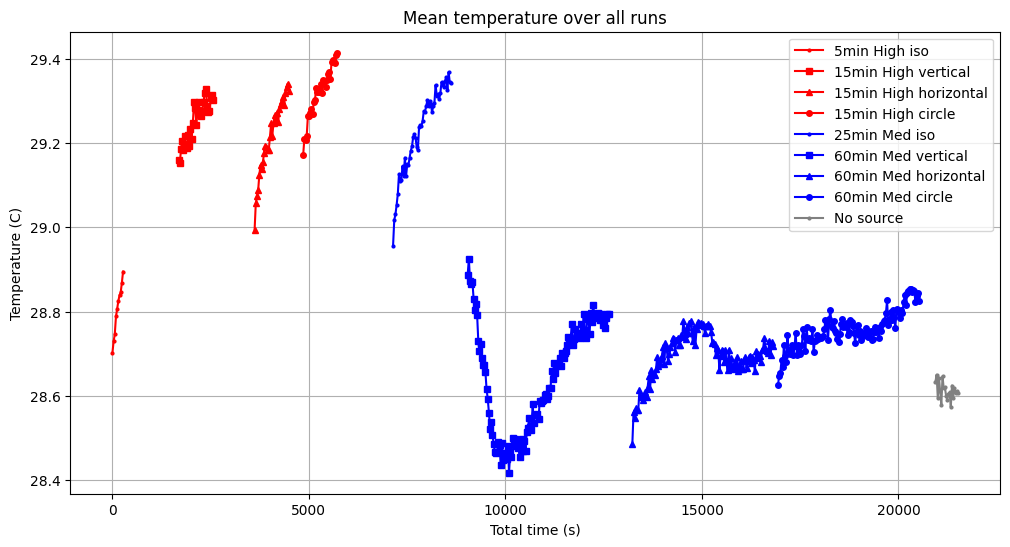

In [9]:
plt.figure(figsize = (12, 6))
plt.plot(times[0:10], np.mean(temps, axis = 1)[0:10], '.-', markersize = 4, color  = 'red', label = '5min High iso')
plt.plot(times[13:43], np.mean(temps, axis = 1)[13:43], 's-', markersize = 4, color = 'red', label = '15min High vertical')
plt.plot(times[43:73], np.mean(temps, axis = 1)[43:73], '^-', markersize = 4, color = 'red', label = '15min High horizontal')
plt.plot(times[73:103], np.mean(temps, axis = 1)[73:103], 'o-', markersize = 4, color = 'red', label = '15min High circle')

plt.plot(times[103:153], np.mean(temps, axis = 1)[103:153], '.-', markersize = 4, color = 'blue', label = '25min Med iso')
plt.plot(times[153:273], np.mean(temps, axis = 1)[153:273], 's-', markersize = 4, color = 'blue', label = '60min Med vertical')
plt.plot(times[273:392], np.mean(temps, axis = 1)[273:392], '^-', markersize = 4, color = 'blue', label = '60min Med horizontal')
plt.plot(times[392:512], np.mean(temps, axis = 1)[392:512], 'o-', markersize = 4, color = 'blue', label = '60min Med circle')

plt.plot(times[512:532], np.mean(temps, axis = 1)[512:532], '.-', markersize = 4, color = 'gray', label = 'No source')
plt.legend()
plt.title('Mean temperature over all runs')
plt.xlabel('Total time (s)')
plt.ylabel('Temperature (C)')
plt.grid()
plt.show()

30


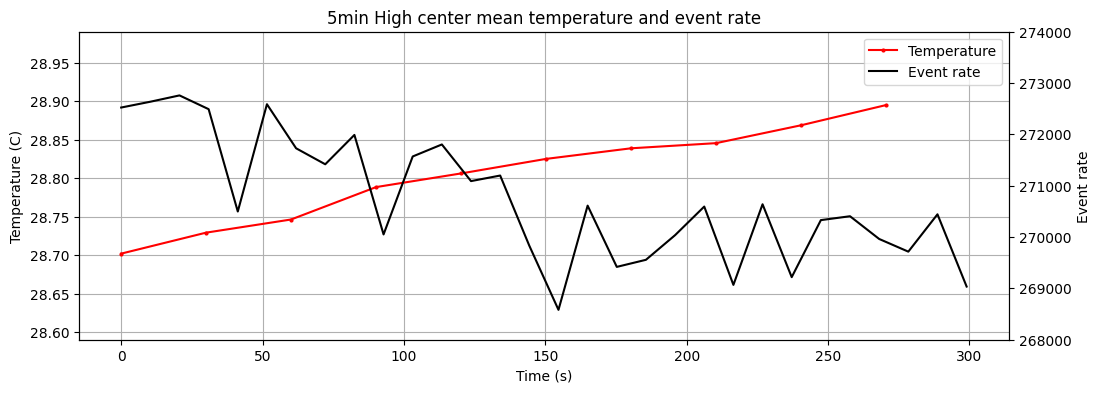

In [48]:
# High iso
plt.figure(figsize = (12, 4))

line1, = plt.plot(times[0:10], np.mean(temps, axis = 1)[0:10], '.-', markersize = 4, color  = 'red', label = '5min High iso')
plt.ylim(28.59, 28.99)
plt.grid()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.twinx()

heights = np.genfromtxt('/home/kale-chen/Documents/PET/MDA_03162026/Data/hcenter_timebinned.txt')
print(len(heights))
line2, = plt.plot(np.linspace(0, 299, len(heights)), heights / 10, color = 'black', label = 'Event rate')
#plt.yticks([1300, 1325, 1350, 1375, 1400, 1425, 1450, 1475, 1500])
plt.ylim(268000, 274000)
plt.legend([line1, line2], ['Temperature', 'Event rate'])
plt.title('5min High center mean temperature and event rate')
plt.ylabel('Event rate')
plt.show()

150


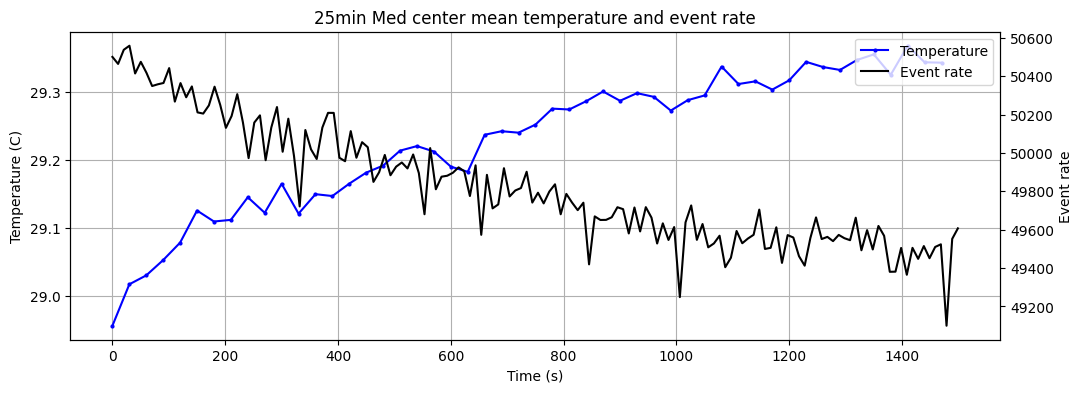

In [53]:
# Med iso
plt.figure(figsize = (12, 4))

line1, = plt.plot(np.linspace(0, 1470, 50), np.mean(temps, axis = 1)[103:153], '.-', markersize = 4, color = 'blue', label = '25min Med iso')

#plt.ylim(28.39, 28.89)
plt.grid()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.twinx()

heights = np.genfromtxt('/home/kale-chen/Documents/PET/MDA_03162026/Data/mcenter_timebinned.txt')
print(len(heights))
line2, = plt.plot(np.linspace(0, 1499, len(heights)), heights / 10, color = 'black', label = 'Event rate')
#plt.yticks([1300, 1325, 1350, 1375, 1400, 1425, 1450, 1475, 1500])
#plt.ylim(1290, 1510)
plt.legend([line1, line2], ['Temperature', 'Event rate'])
plt.title('25min Med center mean temperature and event rate')
plt.ylabel('Event rate')

#plt.grid()
plt.show()

90


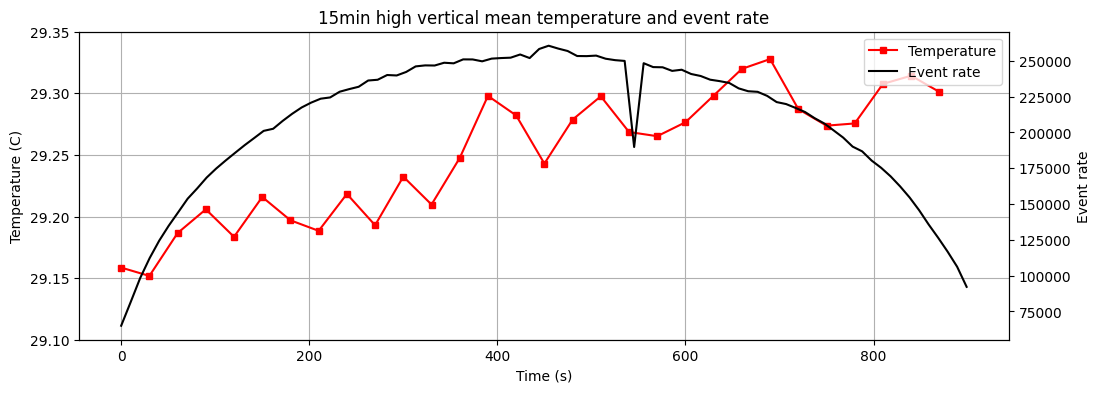

In [63]:
# Hvert
plt.figure(figsize = (12, 4))

line1, = plt.plot(np.linspace(0, 870, 30), np.mean(temps, axis = 1)[13:43], 's-', markersize = 4, color = 'red', label = '15min High vertical')

plt.ylim(29.1, 29.35)
plt.grid()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.twinx()

heights = np.genfromtxt('/home/kale-chen/Documents/PET/MDA_03162026/Data/hvert_timebinned.txt')
print(len(heights))
line2, = plt.plot(np.linspace(0, 899, len(heights)), heights / 10, color = 'black', label = 'Event rate')
#plt.yticks([1300, 1325, 1350, 1375, 1400, 1425, 1450, 1475, 1500])
#plt.ylim(1290, 1510)
plt.legend([line1, line2], ['Temperature', 'Event rate'])
plt.title('15min high vertical mean temperature and event rate')
plt.ylabel('Event rate')

#plt.grid()
plt.show()

360


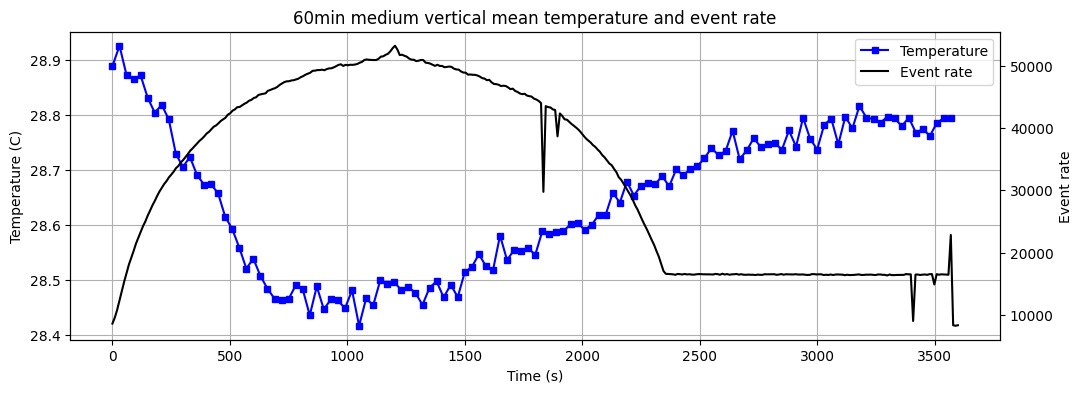

In [67]:
# Hvert
plt.figure(figsize = (12, 4))

line1, = plt.plot(np.linspace(0, 3570, 120), np.mean(temps, axis = 1)[153:273], 's-', markersize = 4, color = 'blue', label = '60min Med vertical')

#plt.ylim(29.1, 29.35)
plt.grid()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.twinx()

heights = np.genfromtxt('/home/kale-chen/Documents/PET/MDA_03162026/Data/mvert_timebinned.txt')
print(len(heights))
line2, = plt.plot(np.linspace(0, 3599, len(heights)), heights / 10, color = 'black', label = 'Event rate')
#plt.yticks([1300, 1325, 1350, 1375, 1400, 1425, 1450, 1475, 1500])
#plt.ylim(1290, 1510)
plt.legend([line1, line2], ['Temperature', 'Event rate'])
plt.title('60min medium vertical mean temperature and event rate')
plt.ylabel('Event rate')

#plt.grid()
plt.show()

60


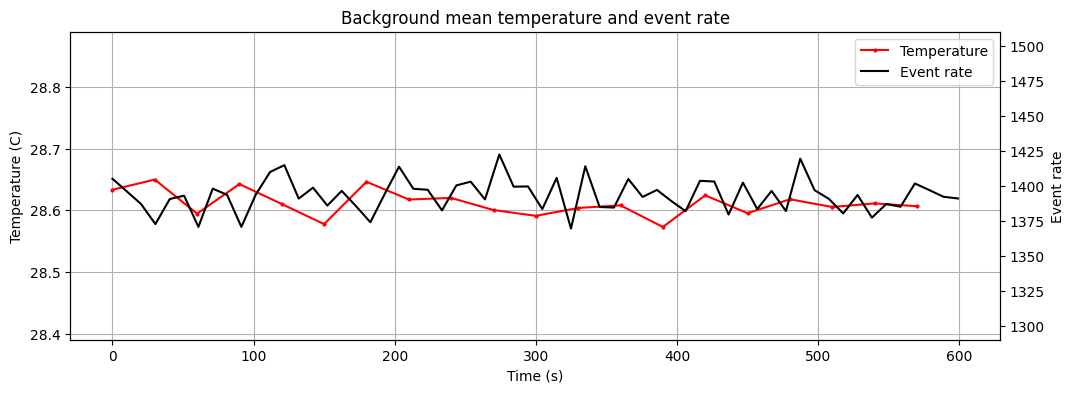

In [ ]:
# Background
plt.figure(figsize = (12, 4))

#plt.plot(times[0:10], np.mean(temps, axis = 1)[0:10], '.-', markersize = 4, color  = 'red', label = '5min High iso')
#plt.plot(times[13:43], np.mean(temps, axis = 1)[13:43], 's-', markersize = 4, color = 'red', label = '15min High vertical')
#plt.plot(times[43:73], np.mean(temps, axis = 1)[43:73], '^-', markersize = 4, color = 'red', label = '15min High horizontal')
#plt.plot(times[73:103], np.mean(temps, axis = 1)[73:103], 'o-', markersize = 4, color = 'red', label = '15min High circle')

#plt.plot(times[103:153], np.mean(temps, axis = 1)[103:153], '.-', markersize = 4, color = 'blue', label = '25min Med iso')
#plt.plot(times[153:273], np.mean(temps, axis = 1)[153:273], 's-', markersize = 4, color = 'blue', label = '60min Med vertical')
#plt.plot(times[273:392], np.mean(temps, axis = 1)[273:392], '^-', markersize = 4, color = 'blue', label = '60min Med horizontal')
#plt.plot(times[392:512], np.mean(temps, axis = 1)[392:512], 'o-', markersize = 4, color = 'blue', label = '60min Med circle')

line1, = plt.plot(np.linspace(0, 570, 20), np.mean(temps, axis = 1)[512:532], '.-', markersize = 4, color = 'red', label = 'Temperature')
plt.ylim(28.39, 28.89)
plt.grid()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.twinx()

heights = np.genfromtxt('/home/kale-chen/Documents/PET/MDA_03162026/Data/background_timebinned.txt')
print(len(heights))
line2, = plt.plot(np.linspace(0, 599, len(heights)), heights / 10, color = 'black', label = 'Event rate')
plt.yticks([1300, 1325, 1350, 1375, 1400, 1425, 1450, 1475, 1500])
plt.ylim(1290, 1510)
plt.legend([line1, line2], ['Temperature', 'Event rate'])
plt.title('Background mean temperature and event rate')
plt.ylabel('Event rate')

#plt.grid()
plt.show()

In [163]:
def convertasicID(asicID):
    complist = asicID.split('_')
    asicorsipm = complist[3][0]
    return str(48 * int(complist[0]) + 16 * int(complist[1]) + 2 * int(complist[2]) + 1 * int(complist[3][1])) + asicorsipm

def savetoIDorder(temps, asicsvals, filename):
    tempIDorder = np.zeros(6144, dtype = np.float32)
    for i in range(len(temps)):
        asicval = asicsvals[i]
        for j in range(64):
            tempIDorder[64 * asicval + j] = temps[i]
    tempIDorder = np.array(tempIDorder)
    tempIDorder.tofile(filename)
    


In [ ]:
index = 0
data = pd.DataFrame()
with open('/home/kale-chen/Documents/PET/TPPT2026/tempanalysis/Temp_log.tlog', 'r') as f:
    for line in f:
        if index == 7:
            #print(len(line.split('\t')))
            header = line.split('\t')
            for i in range(len(header[2:])):
                header[2 + i] = convertasicID(header[2 + i])
            nA, nS = 0, 0
            for i in range(len(header[2:])):
                if header[2 + i][-1] == 'A':
                    nA += 1
                else:
                    nS += 1
            data = pd.DataFrame(columns=header)
        elif index > 7:
            #print(len(line.split('\t')))
            data.loc[len(data)] = line.split('\t')
        index += 1
data['System time'] = data['System time'].astype(float) - float(data['System time'].iloc[0])
#print(data)
times = np.array(data['System time'].values)
tempsA = np.array(data.iloc[:, 2::2].values, dtype = float)
tempsS = np.array(data.iloc[:, 3::2].values, dtype = float)
asicIDs = np.asarray(asicIDs)
print(nA, nS, len(tempsA), len(tempsS))

92 92 366 366


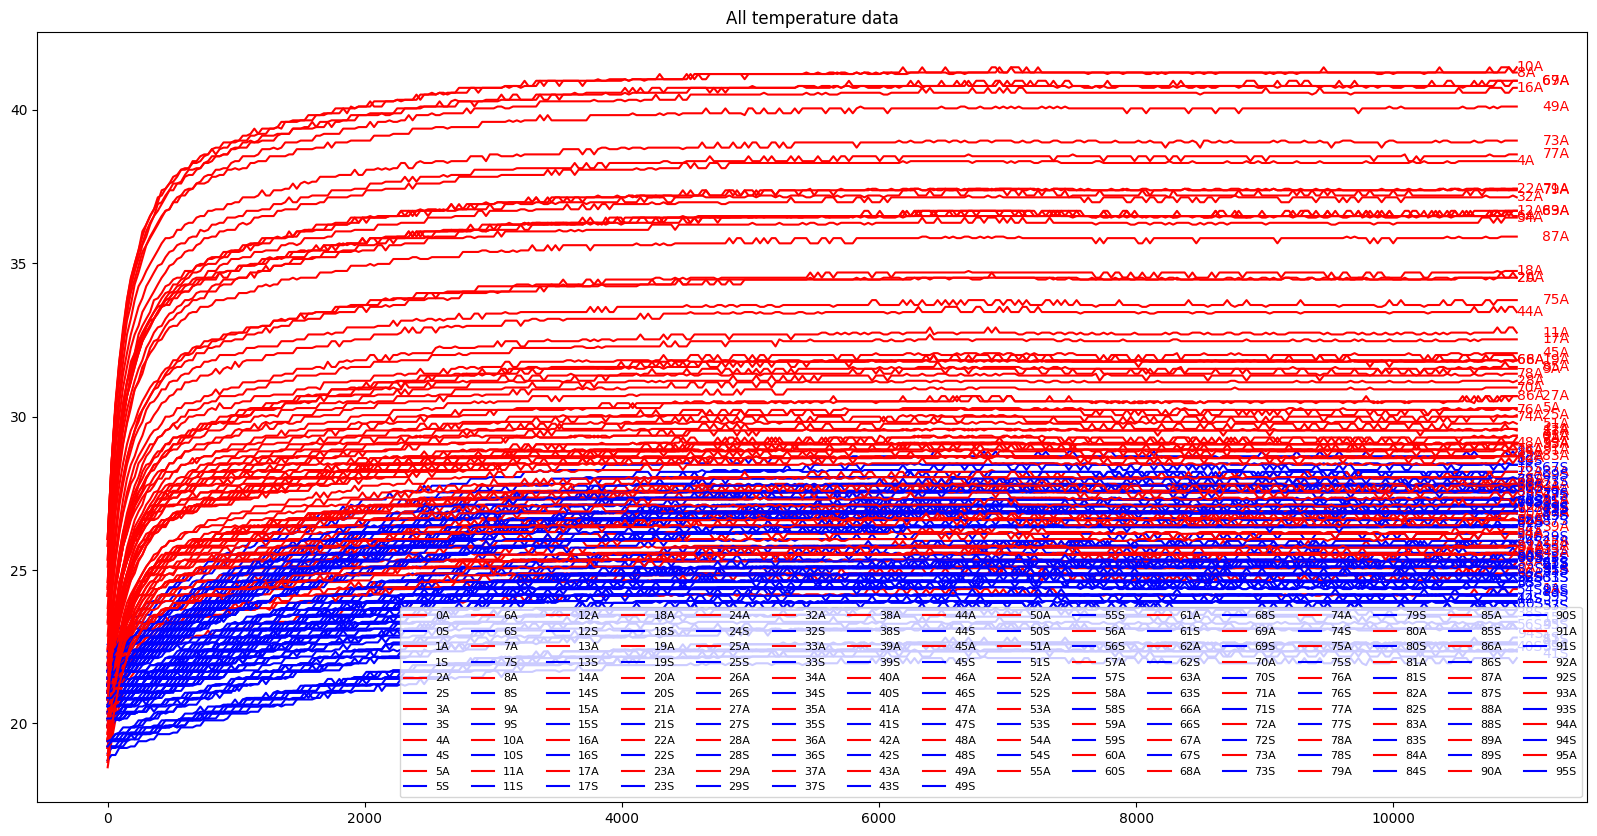

In [195]:
plt.figure(figsize = (20, 10))
counter = 0
for i in range(tempsA.shape[1]):
    plt.plot(times, tempsA[:, i], label = data.columns[2 + i*2], color = 'red')
    plt.plot(times, tempsS[:, i], label = data.columns[3 + i*2], color = 'blue')
    offset = 0 if counter % 2 == 0 else 200
    plt.text(times[-1] + offset, tempsA[-1, i], data.columns[2 + i*2], color = 'red', va = 'center')
    plt.text(times[-1] + offset, tempsS[-1, i], data.columns[3 + i*2], color = 'blue')
    counter += 1
plt.legend(ncols = 16, fontsize = 8, loc = 'lower right')
plt.title('All temperature data')
plt.show()

92 92


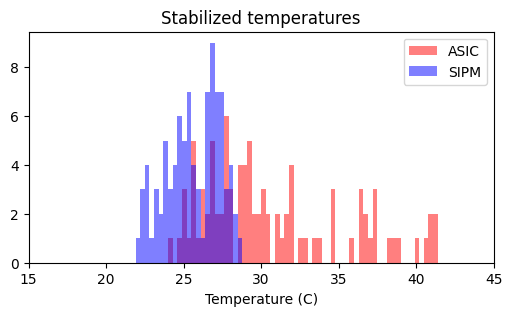

In [172]:
stabtempsA, stabtempsS = [], []
for i in range(tempsA.shape[1]):
    stabtempsA.append(np.mean(tempsA[-20:, i]))
    stabtempsS.append(np.mean(tempsS[-20:, i]))
print(len(stabtempsA), len(stabtempsS))
plt.figure(figsize = (6, 3))
plt.hist(stabtempsA, bins = np.linspace(15, 45, 101), color = 'red', alpha = 0.5, label = 'ASIC')
plt.hist(stabtempsS, bins = np.linspace(15, 45, 101), color = 'blue', alpha = 0.5, label = 'SIPM')
plt.xlim(15, 45)
plt.legend()
plt.title('Stabilized temperatures')
plt.xlabel('Temperature (C)')
plt.show()

In [173]:
asicvalsA = [int(id[:-1]) for id in data.columns[2::2]]
asicvalsS = [int(id[:-1]) for id in data.columns[3::2]]
print(len(asicvalsA), len(asicvalsS))

savetoIDorder(stabtempsA, asicvalsA, '/home/kale-chen/Documents/PET/TPPT2026/tempanalysis/tempIDorderA.bin')
savetoIDorder(stabtempsS, asicvalsS, '/home/kale-chen/Documents/PET/TPPT2026/tempanalysis/tempIDorderS.bin')

92 92


In [194]:
# Find the indices of the max 10 elements in stabtempsA
stabtempsA_np = np.array(stabtempsA)
max_10_indices = np.argsort(stabtempsA_np)[-10:][::-1]
print(asicIDs[max_10_indices])

['0_0_2_A1' '0_0_2_A0' '0_2_1_S0' '0_2_0_S1' '0_0_4_A0' '0_1_3_S1'
 '0_2_2_S0' '0_2_3_S0' '0_0_1_A0' '0_0_5_A1']


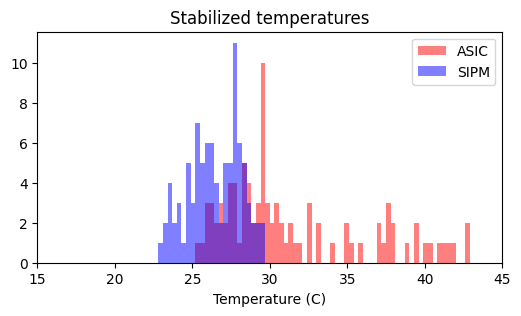

In [168]:
stabtempsA, stabtempsS = [], []
for i in range(92):
    stabtempsA.append(np.mean(temps[:20, i*2]))
for i in range(92):
    stabtempsS.append(np.mean(temps[:20, i*2 + 1]))
plt.figure(figsize = (6, 3))
plt.hist(stabtempsA, bins = np.linspace(15, 45, 101), color = 'red', alpha = 0.5, label = 'ASIC')
plt.hist(stabtempsS, bins = np.linspace(15, 45, 101), color = 'blue', alpha = 0.5, label = 'SIPM')

plt.xlim(15, 45)
plt.legend()
plt.title('Stabilized temperatures')
plt.xlabel('Temperature (C)')
plt.show()
savetoIDorder(stabtempsA, asicvalsA, '/home/kale-chen/Documents/PET/TPPT2026/tempanalysis/tempIDorderAmarch.bin')
savetoIDorder(stabtempsS, asicvalsS, '/home/kale-chen/Documents/PET/TPPT2026/tempanalysis/tempIDorderSmarch.bin')

In [197]:
path = '/home/kale-chen/Documents/PET/TPPT2026/tempanalysis/04252022temps.txt'
temps = pd.read_csv(path, sep = r'\s+')
print(temps)


      portID  slaveID  moduleID  time     A0  Sensor     A1  Sensor.1  S0  \
0          2        0         1  1758  21.00   20.78  20.61     19.87 NaN   
1          2        0         2  1759  23.93   21.73  21.06     20.61 NaN   
2          2        0         4  1759  28.93   24.61  21.45     20.83 NaN   
3          2        0         5  1759  30.28   22.80  22.13     20.78 NaN   
4          2        0         6  1759  23.70   20.16  19.70     18.74 NaN   
...      ...      ...       ...   ...    ...     ...    ...       ...  ..   
2965       2        5         3   129  23.48   28.43  22.41     21.90 NaN   
2966       2        5         4   129  21.73   26.85  21.51     21.51 NaN   
2967       2        5         5   129  21.45   23.25  21.00     20.78 NaN   
2968       2        5         6   129  21.28   23.48  20.83     20.32 NaN   
2969       2        5         7   129  20.55   23.70  18.97     19.48 NaN   

      Sensor.2  S1  Sensor.3  
0          NaN NaN       NaN  
1          Na

90 90


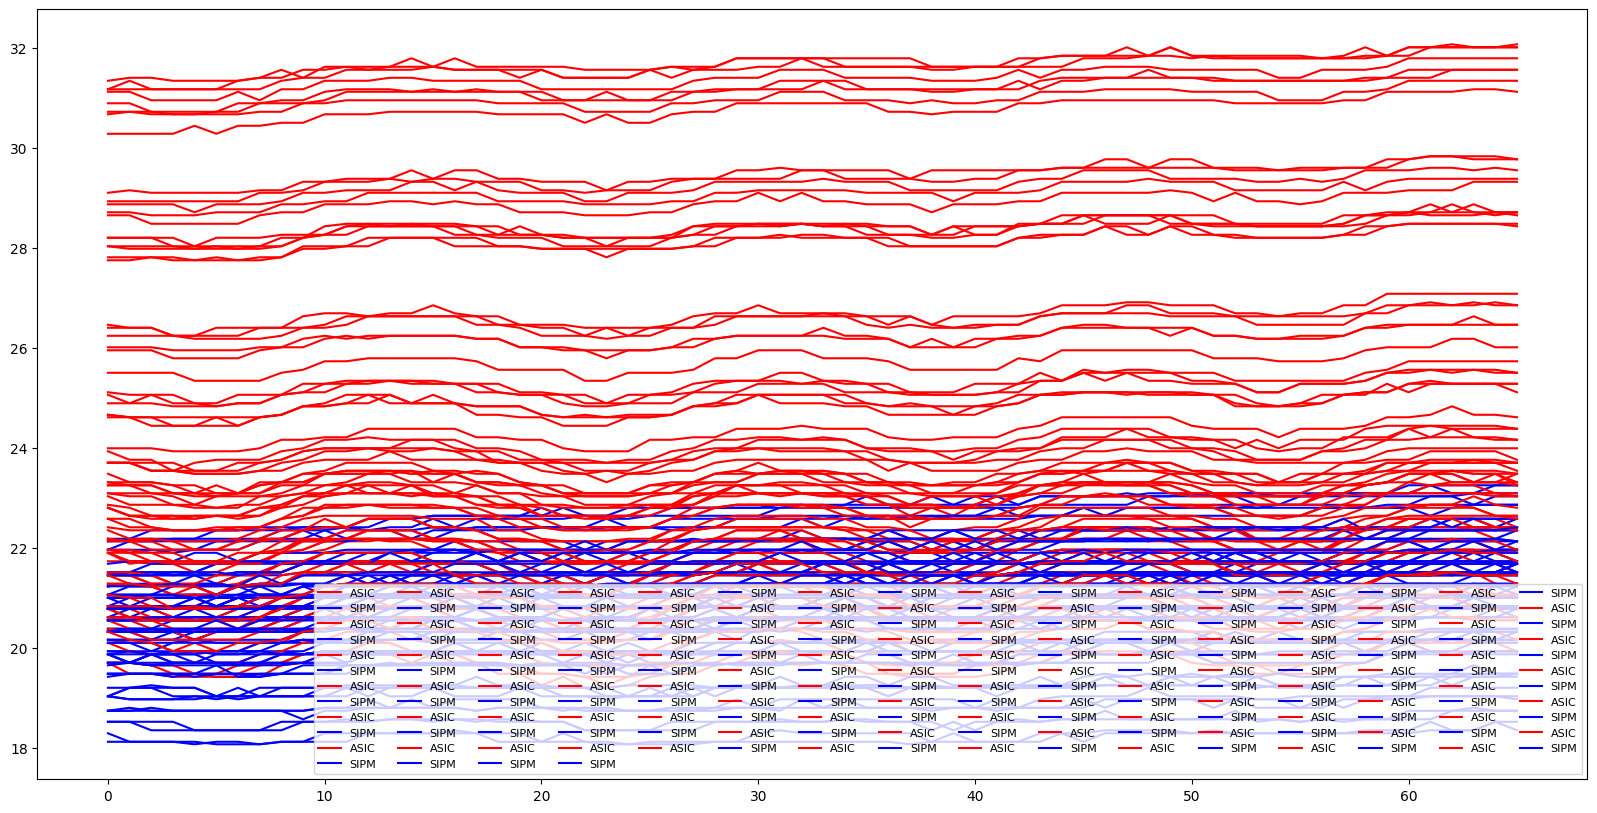

In [ ]:
tempsA, tempsS = [], []
ids = []
for i in range(45):
    currtempA0 = []
    currtempA1 = []
    currtempS0 = []
    currtempS1 = []
    for j in range(2970 // 45):
        currtempA0.append(temps.iloc[j * 45 + i, 4])
        currtempA1.append(temps.iloc[j * 45 + i, 5])
        currtempS0.append(temps.iloc[j * 45 + i, 6])
        currtempS1.append(temps.iloc[j * 45 + i, 7])
    tempsA.append(currtempA0)
    tempsA.append(currtempA1)
    tempsS.append(currtempS0)
    tempsS.append(currtempS1)
    ids.append(temps.iloc[i, 1] * 16 + temps.iloc[i, 2] * 2)
    ids.append(temps.iloc[i, 1] * 16 + temps.iloc[i, 2] * 2 + 1)
tempsA = np.array(tempsA)
tempsS = np.array(tempsS)
print(len(tempsA), len(tempsS))
plt.figure(figsize = (20, 10))
for i in range(len(tempsA)):
    plt.plot(tempsA[i], label = 'ASIC', color = 'red')
    plt.plot(tempsS[i], label = 'SIPM', color = 'blue')
plt.legend(ncols = 16, fontsize = 8, loc = 'lower right')
plt.show()


90 90


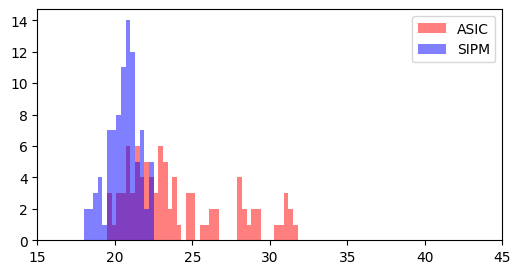

In [212]:
stabtempsA, stabtempsS = [], []
for i in range(90):
    stabtempsA.append(np.mean(tempsA[i, :20]))
    stabtempsS.append(np.mean(tempsS[i, :20]))
print(len(stabtempsA), len(stabtempsS))
plt.figure(figsize = (6, 3))
plt.hist(stabtempsA, bins = np.linspace(15, 45, 101), color = 'red', alpha = 0.5, label = 'ASIC')
plt.hist(stabtempsS, bins = np.linspace(15, 45, 101), color = 'blue', alpha = 0.5, label = 'SIPM')
plt.xlim(15, 45)
plt.legend()
plt.show()
savetoIDorder(stabtempsA, ids, '/home/kale-chen/Documents/PET/TPPT2026/tempanalysis/tempIDorderA2022.bin')
savetoIDorder(stabtempsS, ids, '/home/kale-chen/Documents/PET/TPPT2026/tempanalysis/tempIDorderS2022.bin')

